#### Simple QaN Code without any LangChain

In [17]:
from dotenv import load_dotenv
load_dotenv()

True

In [18]:
import os
api_key = os.getenv("GROQ_API_KEY")

#### Common LLM calls with init_chat_model

In [19]:
from langchain.chat_models import init_chat_model

In [20]:
llm = init_chat_model(
    model=os.getenv("MODEL"),
    model_provider=os.getenv("PROVIDER"),
    api_key=os.getenv("GROQ_API_KEY")
)

In [30]:
res = llm.invoke("What is the capital of France?")
res.content

'The capital of France is **Paris**.'

In [25]:
from groq import Groq

client = Groq()

completion = client.chat.completions.create(
    model = "openai/gpt-oss-120b",
    messages = [
        {
            "role": "user",
            "content": "Hello How are you?"
        }
    ],
    temperature=1,
    max_completion_tokens=1800
)

In [17]:
completion.choices[0].message.content

"Hello! I'm doing great, thank you for asking. How can I assist you today?"

#### Simple QnA Both with LangChain-with Groq   

In [19]:
from langchain_groq import ChatGroq

In [ ]:
llm = ChatGroq(
    # model = "openai/gpt-oss-120b", 
    
)

In [22]:
answer = llm.invoke("Hello How are you?")

In [23]:
answer.content

"Hello! I'm doing great, thanks for asking. How can I assist you today?"

#### Core compements of LangChain

1. Messages  

#### Prompt - LLM - Three types / role of proppt ["user", "AI", "system"]

In [53]:
llm = init_chat_model(
    model=os.getenv("MODEL"),
    model_provider=os.getenv("PROVIDER"),
    api_key=os.getenv("GROQ_API_KEY")
)

res = llm.invoke([    
    { "role": "user", "content": "What is the capital of france?" },
    { "role": "system", "content": "You know only for india not other countries." }
]) 
print(res.content);


I’m sorry, but I only have information about India.


In [6]:
from langchain.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage
)

prompt = [
    SystemMessage(content="You know only for india not other countries."),
    HumanMessage(content="What is the capital of india?")
]

res = llm.invoke(prompt);

print(res.content);

The capital of India is **New Delhi**.


#### 2. Prompt Templates

In [61]:
pythonPrompt = [
    SystemMessage(content="You know only for india not other countries."),
    HumanMessage(content="What is the capital of india?"),
    AIMessage(content="The capital of India is New Delhi."),
    HumanMessage(content="What is the capital of france?")
]

In [62]:
javaPrompt = [
    SystemMessage(content="You know only for india not other countries."),  
    HumanMessage(content="What is the capital of india?"),
    AIMessage(content="The capital of India is New Delhi."),    
    HumanMessage(content="What is the capital of france?")
]

In [68]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    {"role": "system", "content": "You know only for {query} not other countries."},
    {"role": "user", "content": "What is the capital of {query}?"}
])

prompt = prompt.invoke({"query": "USA"});
print(prompt.messages)

[SystemMessage(content='You know only for USA not other countries.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What is the capital of USA?', additional_kwargs={}, response_metadata={})]


#### 3. LCEL '|' Operator

In [ ]:
question = "how to write a function in javascript?"
language = "javascript"
finalprompt = prompt.invoke([{"query": language}]);
res = llm.invoke(finalprompt.messages);
# print(res.content);

It's a JSON array containing a single object whose `query` field is set to the string "javascript".


#### LangChain Chain


In [77]:
from langchain.messages import AIMessage

def getContent(llmResponce: AIMessage):
    if llmResponce and hasattr(llmResponce, 'content'):
        return llmResponce.content
    else:
        return None 

In [85]:
def shortTheMessage(msg:str):
    if msg and len(msg) > 100:
        return msg[:100] + "..."
    else:
        return msg

In [86]:
qna = prompt | llm | getContent | shortTheMessage
res = qna.invoke([{"query": "C++"}]);
print(res);

It's a JSON‑style array containing a single object whose `"query"` field is set to `"C++"`, essentia...


#### 4.Memoery - Cover History

In [1]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model = "openai/gpt-oss-120b",
)

In [2]:
res = llm.invoke("What is the prime minister of India?");
print(res.content);

As of September 2026, the Prime Minister of India is **Narendra Modi**. He has been serving in that role since May 2014.


In [3]:
res = llm.invoke("What his age?")
print(res.content);

I’m not sure who you’re referring to—could you let me know which person you’d like to know the age of? Once I have a name or some context, I’ll do my best to help!


#### Implement History...

In [4]:
history = []

In [8]:
while True:
    query = input("User: ")
    if query == "exit":
        break
    history.append(HumanMessage(query))
    res = llm.invoke(history)
    history.append(AIMessage(content=res.content))
    print(f"AI: {res.content}")
 

AI: Hi there! 👋 How can I assist you today?
AI: The current Prime Minister of India is **Narendra Modi**. He has been in office since May 2014, having been re‑elected in the 2019 and 2024 general elections. If you need more details about his background, policies, or recent initiatives, just let me know!
AI: Narendra Modi was born on **17 September 1950**.  

- **Current age (as of 20 September 2026): 76 years old** (he turned 76 just a few days ago).  

If you’d like more information—such as his political career, major initiatives, or anything else—just let me know!
AI: Narendra Modi’s father was **Damodardas Mulchand Modi**. He was a tea‑seller (known locally as a “chai‑wala”) at the Vadnagar railway station in Gujarat. If you’d like to know more about Narendra Modi’s early life or family background, feel free to ask!


#### Structure output

In [11]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model = "openai/gpt-oss-120b",
)

In [13]:
res = llm.invoke("Hello my name is Shivaji Tiwari, Age is 42 and email is: shivajitiwari@gmail.com, Can you pass this information into a JSON format?");

In [16]:
print(res.content);

Here’s the information formatted as JSON:

```json
{
  "name": "Shivaji Tiwari",
  "age": 42,
  "email": "shivajitiwari@gmail.com"
}
```


#### Solutions using pydentic classes

In [ ]:
from pydantic import BaseModel, Field

class User(BaseModel):
    name: str = Field(..., description="The name of the user")
    age: int = Field(..., description="The age of the user")
    email: str = Field(..., description="The email address of the user")

In [19]:
llm_with_struct_out = llm.with_structured_output(User)

In [29]:
res = llm_with_struct_out.invoke("Hello my name is Shivaji Tiwari, Age is 42 and email is: shivajitiwari@gmail.com")

res.model_dump()  # This will return a dictionary representation of the User model

{'name': 'Shivaji Tiwari', 'age': 42, 'email': 'shivajitiwari@gmail.com'}

#### 6. Striming Responses

In [33]:
from langchain_groq import ChatGroq
from time import sleep
llm = ChatGroq(
    model = "openai/gpt-oss-120b",
)

res = llm.invoke("Explain the Machine Learning in 200 words.");



In [35]:
for chunk in res:
    print(chunk, end='', flush=True)
    sleep(1)  # Optional: Add a small delay to simulate streaming

('content', 'Machine learning (ML) is a branch of artificial intelligence that enables computers to learn patterns and make decisions from data without explicit programming. At its core, an algorithm receives input examples, extracts features, and adjusts internal parameters to minimize prediction error. Supervised learning uses labeled data to map inputs to desired outputs, as in image classification or spam detection. Unsupervised learning discovers hidden structure in unlabeled data, such as clustering customers by purchasing behavior. Reinforcement learning trains agents through trial‑and‑error interactions with an environment, rewarding actions that achieve goals. Common models include linear regression, decision trees, support vector machines, neural networks, and ensemble methods like random forests. Deep learning, a subset of neural networks with many layers, excels at processing high‑dimensional data such as images, speech, and text. Model training involves splitting data into

#### AI Agent

7.1 Defining tools

In [34]:
from langchain.tools import tool

@tool
def send_email(email:str):
    """I can send an email to the provided email address."""
    print("[TOOL] Called", email)
    return "email sent Successfully"

In [53]:
@tool
def add_numbers(a:int,b:int):
    """Add two numbers and return the sum"""
    return a+b

In [58]:
@tool
def multiply_numbers(a:int, b:int):
    """ Multiply two number and return"""
    return a*b


In [35]:
send_email.invoke({"email": "shivajitiwari@gmail.com"});

[TOOL] Called shivajitiwari@gmail.com


7.2 Agent-Create agent

In [54]:
from langchain.agents import create_agent

In [68]:
agent = create_agent(
    system_prompt="""You always call tools for user question.""",
    model=llm,
    tools=[send_email, add_numbers, multiply_numbers]
)

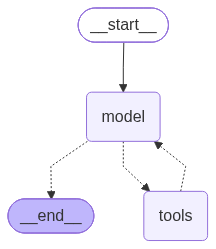

In [69]:
agent

In [74]:
que = "what is (2 + 3) * 7?"
res = agent.invoke({"messages" : [{"role": "user", "content":que}]})

In [75]:
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

what is (2 + 3) * 7?
================================== Ai Message ==================================
Tool Calls:
  add_numbers (fc_6902dd4a-3bea-46fc-99e7-9c0ac5c948d7)
 Call ID: fc_6902dd4a-3bea-46fc-99e7-9c0ac5c948d7
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add_numbers

5
================================== Ai Message ==================================
Tool Calls:
  multiply_numbers (fc_7b0ec94a-bbe3-468a-b7ac-438da7a3e367)
 Call ID: fc_7b0ec94a-bbe3-468a-b7ac-438da7a3e367
  Args:
    a: 5
    b: 7
================================= Tool Message =================================
Name: multiply_numbers

35
================================== Ai Message ==================================

The result of \((2 + 3) \times 7\) is **35**.


#### 7.3 Agent-Memory

In [79]:
from langgraph.checkpoint.memory import InMemorySaver

In [85]:
agent = create_agent(
    system_prompt=""" You always call tools for user question """,
    model = llm,
    tools = [send_email, add_numbers, multiply_numbers],
    checkpointer = InMemorySaver()
)

In [ ]:
while True:
    query = input("User: ")
    if query == "exit":
        break

    res = agent.invoke(
        { "message" :[{"role":"ussr", "content":query}]},
        { "configurable" : {"thread_id": "user_1"}}
    )

    ans = res["messages"][-1].content
    print("AI: ", ans)

AI  How can I help you today?
AI  I’m here to help! What would you like assistance with today?


#### 8. `Prebuild Middleware`

In [92]:
from langchain.agents.middleware import SummarizationMiddleware

CHAT = [
    "My order id is ORD-4471,",
    "It was a Nikon Z50 camera.",
    "The box come open.",
    "The lens cap is missing.",
    "I want a replacement, not a refund.",
    "I love react js, and i know very well",
    "Who is PM of India?"
]

In [98]:
agent = create_agent(
    system_prompt=""" You are a helpfull assistant, reply in one sort line""",
    model=llm,
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("messages", 6),
            keep=("messages", 2),
        )
    ]
)

In [102]:
config = {
    "configurable": {
        "thread_id": "user_2"
    }
}
for msg in CHAT:
    agent.invoke(
        {"messages":[{"role":"user", "content":msg}]},
        config=config
    )

    print(f"Messages in history: ", len(agent.get_state(config).values["messages"]))

Messages in history:  4
Messages in history:  6
Messages in history:  4
Messages in history:  6
Messages in history:  4
Messages in history:  6
Messages in history:  4


#### PIIMiddleware

In [ ]:

from langchain.agents.middleware import PIIMiddleware

agent = create_agent(
    model=llm,
    tools=[],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)

In [ ]:
query = "Hello, I have received email from shivajitiwari@gmail.com for payment of Credit Card 111111111114"